- Configuração do seu ambiente

Crie um ambiente virtual python: python3 -m venv venv

Ative o seu ambiente virtual: source venv/bin/activate

Instale as dependências usando o 'requirements.txt' deste repositório: pip install -r requirements.txt

Crie um kernel no seu jupyter notebook com o seu novo ambiente. Para isso:

Com o jupyter notebook aberto clique em "Select Kernel" no canto superior direito

Crie um novo kernel usando um ambiente python existente, neste caso o que você acabou de criar

- Descrição da atividade

Você tem acesso a uma base de dados chamada "fashion_mnist". Essa base de dados possui várias imagens, já processadas e em formato de matriz, de roupas de vários estilos classificadas de acordo com as seguintes classes:

T-shirt/top (camiseta)

Trouser (calça)

Pullover (suéter)

Dress (vestido)

Coat (casaco)

Sandal (sandália)

Shirt (camisa)

Sneaker (tênis)

Bag (bolsa)

Ankle boot (bota de cano curto)

O frio está passando e você deve criar uma CNN com keras para identificar roupas adequadas para o verão. Portanto, podemos transformar esse problema em uma classificação binária: 0 - Frio, 1 - Calor. Organize os dados e crie uma rede que consiga realizar essa classificação.

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np

2025-08-23 02:01:47.789433: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-23 02:01:51.885722: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-23 02:01:53.644473: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755914516.708592    5110 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755914517.513066    5110 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755914523.802449    5110 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
# Carregar dados
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Formato original dos dados:")
print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")

Formato original dos dados:
x_train: (60000, 28, 28), y_train: (60000,)
x_test: (10000, 28, 28), y_test: (10000,)


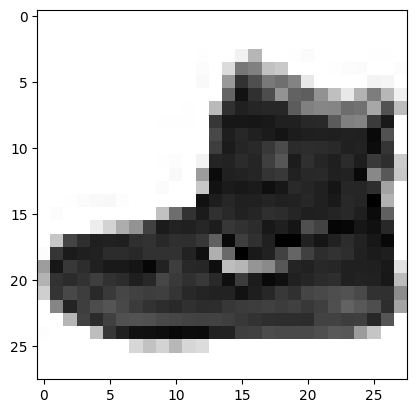

Label original: 9


In [3]:
# Visualizar exemplo
plt.imshow(x_train[0].reshape(28,28), cmap=plt.cm.binary)
plt.show()
print('Label original: {}'.format(y_train[0]))

In [4]:
# Normalizar para melhorar o treinamento
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Incluir canal de cor
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

print("\nFormato após preprocessamento:")
print(f"x_train: {x_train.shape}, x_test: {x_test.shape}")


Formato após preprocessamento:
x_train: (60000, 28, 28, 1), x_test: (10000, 28, 28, 1)


In [5]:
# Mapeamento das classes originais para classificação binária
# Classes originais do Fashion-MNIST:
# 0: T-shirt/top (camiseta) -> CALOR (1)
# 1: Trouser (calça) -> FRIO (0) - pode ser usada no frio
# 2: Pullover (suéter) -> FRIO (0)
# 3: Dress (vestido) -> CALOR (1)
# 4: Coat (casaco) -> FRIO (0)
# 5: Sandal (sandália) -> CALOR (1)
# 6: Shirt (camisa) -> CALOR (1)
# 7: Sneaker (tênis) -> CALOR (1) - mais usado no calor
# 8: Bag (bolsa) -> CALOR (1) - neutro, mas vamos considerar calor
# 9: Ankle boot (bota de cano curto) -> FRIO (0)

# Mapping: 0=FRIO, 1=CALOR
class_mapping = {
    0: 1,  # T-shirt/top -> CALOR
    1: 0,  # Trouser -> FRIO
    2: 0,  # Pullover -> FRIO
    3: 1,  # Dress -> CALOR
    4: 0,  # Coat -> FRIO
    5: 1,  # Sandal -> CALOR
    6: 1,  # Shirt -> CALOR
    7: 1,  # Sneaker -> CALOR
    8: 1,  # Bag -> CALOR
    9: 0   # Ankle boot -> FRIO
}

# Aplicar o mapeamento binário
y_train_binary = np.array([class_mapping[label] for label in y_train])
y_test_binary = np.array([class_mapping[label] for label in y_test])

print("\nDistribuição das classes binárias:")
print(f"Treino - Frio (0): {np.sum(y_train_binary == 0)}, Calor (1): {np.sum(y_train_binary == 1)}")
print(f"Teste - Frio (0): {np.sum(y_test_binary == 0)}, Calor (1): {np.sum(y_test_binary == 1)}")


Distribuição das classes binárias:
Treino - Frio (0): 24000, Calor (1): 36000
Teste - Frio (0): 4000, Calor (1): 6000


In [6]:
# Converter para categorical (one-hot encoding) para 2 classes
y_train_categorical = tf.keras.utils.to_categorical(y_train_binary, 2)
y_test_categorical = tf.keras.utils.to_categorical(y_test_binary, 2)

# Criar o modelo CNN
model = Sequential([
    # Primeira camada convolucional
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(2, 2),
    
    # Segunda camada convolucional
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Terceira camada convolucional
    Conv2D(128, (3, 3), activation='relu'),
    
    # Flatten e camadas densas
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    
    # Camada de saída para classificação binária
    Dense(2, activation='softmax')
])

# Compilar o modelo
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Exibir arquitetura do modelo
print("\nArquitetura do modelo:")
model.summary()

/home/codespace/.local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-08-23 02:02:31.444506: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



Arquitetura do modelo:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,514 (939.51 KB)

 Trainable params: 240,514 (939.51 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
print("\nIniciando treinamento...")
history = model.fit(
    x_train, y_train_categorical,
    batch_size=32,
    epochs=10,
    validation_data=(x_test, y_test_categorical),
    verbose=1
)

# Avaliar o modelo
test_loss, test_accuracy = model.evaluate(x_test, y_test_categorical, verbose=0)
print(f"\nAcurácia no teste: {test_accuracy:.4f}")


Iniciando treinamento...
Epoch 1/10


2025-08-23 02:02:32.043450: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 19ms/step - accuracy: 0.8679 - loss: 0.2900 - val_accuracy: 0.9256 - val_loss: 0.1731
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9347 - loss: 0.1604 - val_accuracy: 0.9374 - val_loss: 0.1557
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9409 - loss: 0.1451 - val_accuracy: 0.9431 - val_loss: 0.1408
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9476 - loss: 0.1314 - val_accuracy: 0.9435 - val_loss: 0.1363
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.9509 - loss: 0.1213 - val_accuracy: 0.9499 - val_loss: 0.1284
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9537 - loss: 0.1168 - val_accuracy: 0.9493 - val_loss: 0.1246
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9547 - loss: 0.1108 - val_accuracy: 0.9474 - val_loss: 0.1295
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9603 - loss: 0.10

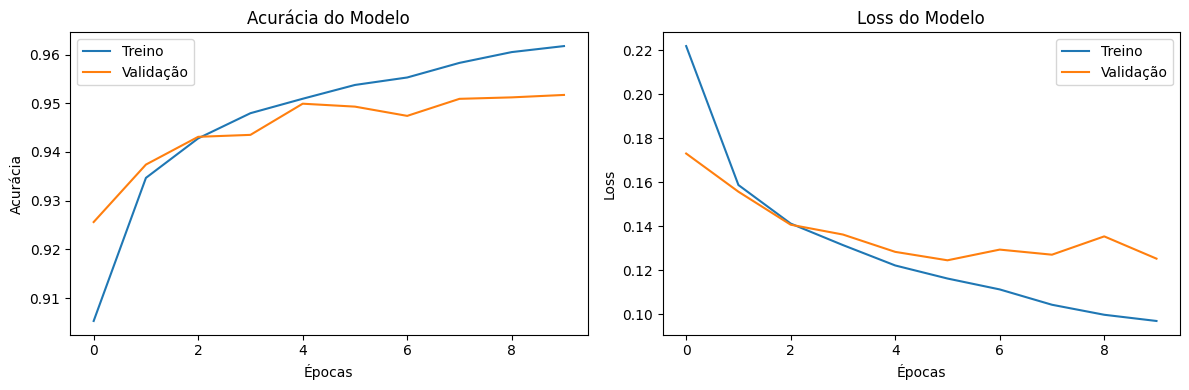

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


In [8]:
# Plotar histórico de treinamento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia do Modelo')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss do Modelo')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Fazer predições em algumas amostras
predictions = model.predict(x_test[:10])
predicted_classes = np.argmax(predictions, axis=1)

In [9]:
print("\nPredições em amostras de teste:")
class_names_binary = ['Frio', 'Calor']
for i in range(10):
    true_class = y_test_binary[i]
    pred_class = predicted_classes[i]
    confidence = np.max(predictions[i]) * 100
    
    print(f"Amostra {i+1}: Real={class_names_binary[true_class]}, "
          f"Predito={class_names_binary[pred_class]}, "
          f"Confiança={confidence:.1f}%")


Predições em amostras de teste:
Amostra 1: Real=Frio, Predito=Frio, Confiança=100.0%
Amostra 2: Real=Frio, Predito=Frio, Confiança=100.0%
Amostra 3: Real=Frio, Predito=Frio, Confiança=100.0%
Amostra 4: Real=Frio, Predito=Frio, Confiança=100.0%
Amostra 5: Real=Calor, Predito=Calor, Confiança=91.2%
Amostra 6: Real=Frio, Predito=Frio, Confiança=100.0%
Amostra 7: Real=Frio, Predito=Frio, Confiança=100.0%
Amostra 8: Real=Calor, Predito=Calor, Confiança=98.1%
Amostra 9: Real=Calor, Predito=Calor, Confiança=100.0%
Amostra 10: Real=Calor, Predito=Calor, Confiança=100.0%


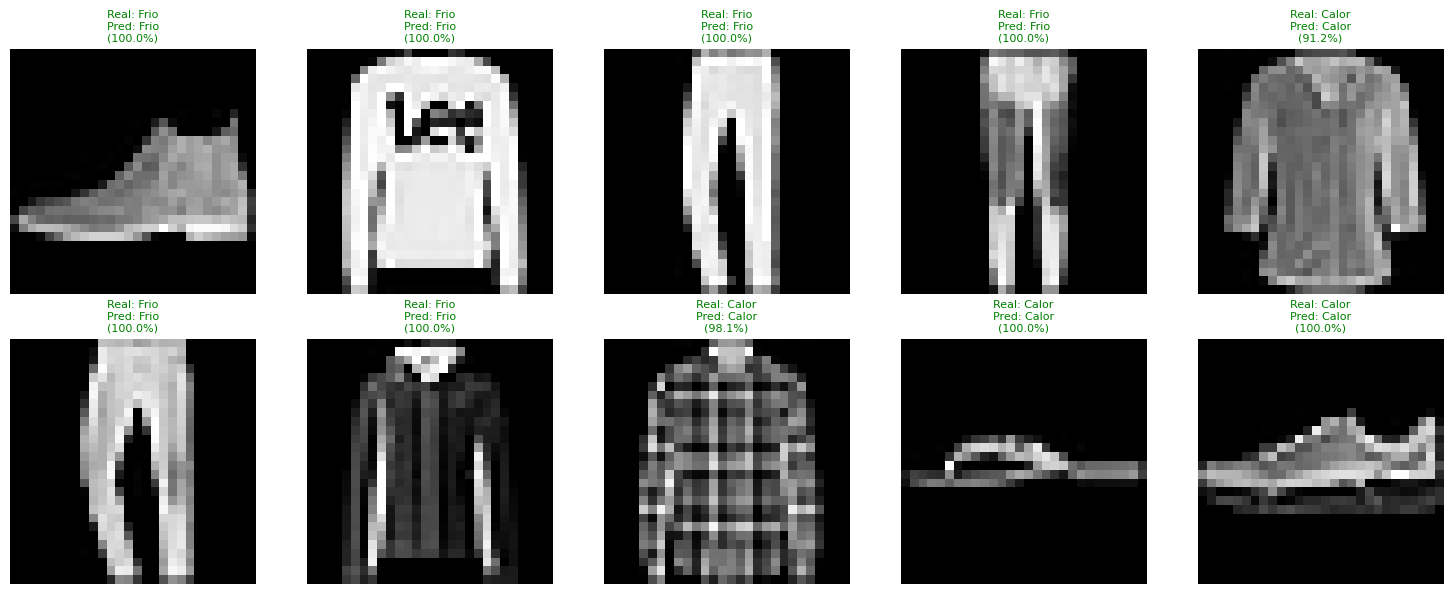


Modelo treinado com sucesso!
0 = Roupas de Frio (Trouser, Pullover, Coat, Ankle boot)
1 = Roupas de Calor (T-shirt/top, Dress, Sandal, Shirt, Sneaker, Bag)


In [10]:
# Visualizar algumas predições
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    true_class = y_test_binary[i]
    pred_class = predicted_classes[i]
    confidence = np.max(predictions[i]) * 100
    
    color = 'green' if true_class == pred_class else 'red'
    plt.title(f'Real: {class_names_binary[true_class]}\n'
              f'Pred: {class_names_binary[pred_class]}\n'
              f'({confidence:.1f}%)', color=color, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

print("\nModelo treinado com sucesso!")
print("0 = Roupas de Frio (Trouser, Pullover, Coat, Ankle boot)")
print("1 = Roupas de Calor (T-shirt/top, Dress, Sandal, Shirt, Sneaker, Bag)")

...